In [1]:
import numpy as np
import numpy as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("heart.csv")

In [4]:
print(df.head(10))

print("Shape:", df.shape)

print(df.info())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1     

In [5]:
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [6]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (918, 12)


In [7]:
chol_zero = (df["Cholesterol"] == 0).sum()
bp_zero = (df["RestingBP"] == 0).sum()

print("Cholesterol = 0 :", chol_zero)
print("RestingBP = 0 :", bp_zero)

Cholesterol = 0 : 172
RestingBP = 0 : 1


In [8]:
print("Before Cleaning")
print(df[["Cholesterol", "RestingBP"]].describe())

chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

df.loc[df["Cholesterol"] == 0, "Cholesterol"] = chol_mean
df.loc[df["RestingBP"] == 0, "RestingBP"] = bp_mean

df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

print("\nAfter Cleaning")
print(df[["Cholesterol", "RestingBP"]].describe())

Before Cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

After Cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


/tmp/ipykernel_2857/171643605.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '244.6353887399464' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df["Cholesterol"] == 0, "Cholesterol"] = chol_mean
/tmp/ipykernel_2857/171643605.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '132.54089422028352' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df["RestingBP"] == 0, "RestingBP"] = bp_mean


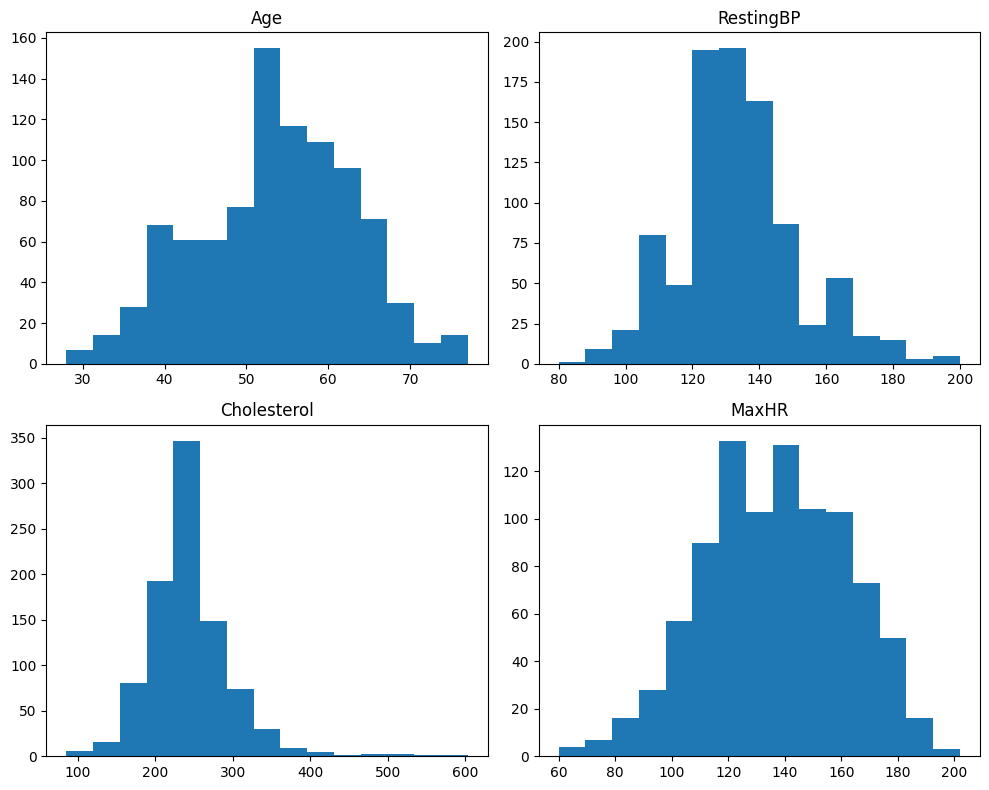

In [9]:
def plot_histograms(data):
    cols = ["Age", "RestingBP", "Cholesterol", "MaxHR"]

    plt.figure(figsize=(10,8))

    for i, col in enumerate(cols):
        plt.subplot(2,2,i+1)
        plt.hist(data[col], bins=15)
        plt.title(col)

    plt.tight_layout()
    plt.show()

plot_histograms(df)

In [10]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(list(num_cols))

print("\nCategorical Columns:")
print(list(cat_cols))

Numerical Columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

Categorical Columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [11]:
df_encoded = pd.get_dummies(df)

print("Shape:", df_encoded.shape)

print(df_encoded.head())

Shape: (918, 21)
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LVH  RestingECG_Normal  RestingECG_ST

In [12]:
print("Final Shape:", df_encoded.shape)

print(df_encoded.columns.tolist())

Final Shape: (918, 21)
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [ ]:
# Summary
# 1. Invalid values found:
#    - Cholesterol = 0
#    - RestingBP = 0
#    These were replaced with the mean (excluding zero values).
# 2. Invalid values can affect analysis and machine learning accuracy.
# 3. One-Hot Encoding converts categorical data into numeric columns so ML algorithms can process them.
# 4. Duplicate rows were removed (if any), invalid values were cleaned,and the dataset became ready for analysis and model building.